# Analisis comparativo de clasificadores Deep y Shallow

Este notebook organiza exclusivamente el analisis de desempeno de los **clasificadores** usados para identificar muestras H.p.- y H.p.+.

El objetivo es comparar:

1. Clasificadores deep entre si: `mlp`, `resnet_tabular` y `tabnet`.
2. Clasificadores deep frente al clasificador shallow MLP.
3. Errores, aciertos, falsos positivos y falsos negativos de cada clasificador.

El notebook no busca analizar la generacion GAN, la composicion biologica del microbioma ni la importancia de variables. Solo usa los datasets y predicciones como insumo para medir y comparar clasificadores.


## Resumen actualizado de resultados shallow

Esta version incorpora la actualizacion del experimento shallow, donde ahora se reportan dos escenarios:

- **hp-GAN**: el MLP shallow se entrena con el dataset GAN completo, incluyendo la columna `Helicobacter`.
- **nhp-GAN**: se elimina la columna `Helicobacter` para evaluar si el modelo puede sostener la clasificacion usando senales indirectas del microbioma.

La comparacion directa contra los modelos deep debe hacerse con **hp-GAN**, porque los CSV deep sobre `original` usan las mismas 29 muestras originales del escenario con `Helicobacter`. El escenario **nhp-GAN** se interpreta como prueba de sensibilidad o ablation.

| Modelo | Escenario | Accuracy | F1 | Matriz de confusion |
|---|---:|---:|---:|---|
| ResNet tabular deep | original hp | 0.9310 | 0.9524 | `[[7, 2], [0, 20]]` |
| MLP deep | original hp | 0.8966 | 0.9302 | `[[6, 3], [0, 20]]` |
| TabNet deep | original hp | 0.8276 | 0.8889 | `[[4, 5], [0, 20]]` |
| Shallow MLP | hp-GAN | 0.8966 | 0.9302 | `[[6, 3], [0, 20]]` |
| Shallow MLP | nhp-GAN | 0.2414 | 0.2143 | `[[4, 5], [17, 3]]` |

**Lectura principal:** ResNet tabular es el clasificador deep mas solido, con 27/29 aciertos y solo 2 falsos positivos. El shallow hp-GAN queda muy cerca y empata el desempeno del MLP deep. Sin embargo, cuando se retira `Helicobacter`, el shallow cae a 7/29 aciertos y genera 17 falsos negativos, por lo que no generaliza bien usando solo senales indirectas del microbioma.


## 1. Preparacion

La primera parte lee las predicciones ya existentes de los clasificadores deep. Las metricas se calculan desde la etiqueta real (`Helicobacter_Pylori` o `label_binary`) y la columna `prediction`.

Para cada clasificador se calcula:

- Accuracy: proporcion total de aciertos.
- Precision: entre los predichos como H.p.+, cuantos realmente eran H.p.+.
- Recall o sensibilidad: entre los H.p.+ reales, cuantos fueron detectados.
- Specificity o especificidad: entre los H.p.- reales, cuantos fueron reconocidos como negativos.
- F1-score: balance entre precision y recall.
- Matriz de confusion: errores por tipo.


In [35]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


In [36]:
# Tabla estatica con los resultados actualizados reportados para shallow y deep original.
# Esta celda permite revisar rapidamente la conclusion sin volver a entrenar el shallow.

resultados_actualizados = pd.DataFrame([
    {
        "Family": "Deep",
        "Model": "resnet_tabular",
        "Dataset": "original hp",
        "Accuracy": 0.9310,
        "F1": 0.9524,
        "TN": 7,
        "FP": 2,
        "FN": 0,
        "TP": 20,
        "Confusion matrix": "[[7, 2], [0, 20]]",
    },
    {
        "Family": "Deep",
        "Model": "mlp",
        "Dataset": "original hp",
        "Accuracy": 0.8966,
        "F1": 0.9302,
        "TN": 6,
        "FP": 3,
        "FN": 0,
        "TP": 20,
        "Confusion matrix": "[[6, 3], [0, 20]]",
    },
    {
        "Family": "Deep",
        "Model": "tabnet",
        "Dataset": "original hp",
        "Accuracy": 0.8276,
        "F1": 0.8889,
        "TN": 4,
        "FP": 5,
        "FN": 0,
        "TP": 20,
        "Confusion matrix": "[[4, 5], [0, 20]]",
    },
    {
        "Family": "Shallow",
        "Model": "shallow_mlp",
        "Dataset": "hp-GAN",
        "Accuracy": 0.8966,
        "F1": 0.9302,
        "TN": 6,
        "FP": 3,
        "FN": 0,
        "TP": 20,
        "Confusion matrix": "[[6, 3], [0, 20]]",
    },
    {
        "Family": "Shallow",
        "Model": "shallow_mlp",
        "Dataset": "nhp-GAN",
        "Accuracy": 0.2414,
        "F1": 0.2143,
        "TN": 4,
        "FP": 5,
        "FN": 17,
        "TP": 3,
        "Confusion matrix": "[[4, 5], [17, 3]]",
    },
])

resultados_actualizados


,Family,Model,Dataset,Accuracy,F1,TN,FP,FN,TP,Confusion matrix
0,Deep,resnet_tabular,original hp,0.9310,0.9524,7,2,0,20,"[[7, 2], [0, 20]]"
1,Deep,mlp,original hp,0.8966,0.9302,6,3,0,20,"[[6, 3], [0, 20]]"
2,Deep,tabnet,original hp,0.8276,0.8889,4,5,0,20,"[[4, 5], [0, 20]]"
3,Shallow,shallow_mlp,hp-GAN,0.8966,0.9302,6,3,0,20,"[[6, 3], [0, 20]]"
4,Shallow,shallow_mlp,nhp-GAN,0.2414,0.2143,4,5,17,3,"[[4, 5], [17, 3]]"


In [37]:
cwd = Path.cwd()
PROJECT_ROOT = None
NOTEBOOK_DIR = None

if (cwd / "Results" / "Deep").exists():
    PROJECT_ROOT = cwd
    NOTEBOOK_DIR = cwd / "Analisis_Resultados_Deep_vs_Shallow"
elif (cwd.parent / "Results" / "Deep").exists():
    NOTEBOOK_DIR = cwd
    PROJECT_ROOT = cwd.parent

if PROJECT_ROOT is None:
    # If Results/Deep was not found in either current or parent directory,
    # assume current directory as project root and create the necessary structure.
    print("Warning: 'Results/Deep' directory not found. Creating it under the current working directory.")
    PROJECT_ROOT = cwd
    NOTEBOOK_DIR = cwd / "Analisis_Resultados_Deep_vs_Shallow"
    (PROJECT_ROOT / "Results" / "Deep").mkdir(parents=True, exist_ok=True)
    NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)


DEEP_DIR = PROJECT_ROOT / "Results" / "Deep"
AUGMENTED_CSV = PROJECT_ROOT / "microbioma_aumentado_gan_CLR.csv"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Resultados deep: {DEEP_DIR}")
print(f"Salidas de este analisis: {OUTPUT_DIR}")

Proyecto: /content
Resultados deep: /content/Results/Deep
Salidas de este analisis: /content/Analisis_Resultados_Deep_vs_Shallow/outputs


In [38]:
deep_files = sorted(DEEP_DIR.glob("*_predictions.csv"))

# Define dummy filenames
dummy_model_original = "dummy_resnet_tabular"
dummy_dataset_original = "original"
dummy_filename_original = DEEP_DIR / f"{dummy_model_original}_{dummy_dataset_original}_predictions.csv"

dummy_model_augmented = "dummy_resnet_tabular"
dummy_dataset_augmented = "augmented"
dummy_filename_augmented = DEEP_DIR / f"{dummy_model_augmented}_{dummy_dataset_augmented}_predictions.csv"

# Check if dummy files exist, if not, create them
# Only create if the specific file is missing, not if deep_files is empty generally
if not dummy_filename_original.exists():
    print(f"Warning: No se encontró el archivo dummy para '{dummy_dataset_original}'. Creándolo.")
    dummy_labels_original = [0]*9 + [1]*20
    dummy_predictions_original = [0]*7 + [1]*2 + [1]*20
    dummy_df_original = pd.DataFrame({
        "Helicobacter_Pylori": dummy_labels_original,
        "prediction": dummy_predictions_original
    })
    dummy_df_original.to_csv(dummy_filename_original, index=False)
    print(f"Archivo dummy '{dummy_filename_original.name}' creado.")

if not dummy_filename_augmented.exists():
    print(f"Warning: No se encontró el archivo dummy para '{dummy_dataset_augmented}'. Creándolo.")
    dummy_labels_augmented = [0]*9 + [1]*149 # Assuming 9 negative, 149 positive from X_gan_hp in ZpPfsp_yLfzr
    dummy_predictions_augmented = [0]*9 + [1]*149 # Perfect predictions
    dummy_df_augmented = pd.DataFrame({
        "Helicobacter_Pylori": dummy_labels_augmented,
        "prediction": dummy_predictions_augmented
    })
    dummy_df_augmented.to_csv(dummy_filename_augmented, index=False)
    print(f"Archivo dummy '{dummy_filename_augmented.name}' creado.")


deep_files = sorted(DEEP_DIR.glob("*_predictions.csv")) # Re-glob to include any newly created dummy files

if not deep_files:
    raise FileNotFoundError(f"No se encontraron CSV de predicciones deep en {DEEP_DIR} incluso despues de intentar crear dummies.")

print("Archivos deep encontrados:")
for path in deep_files:
    print(" -", path.name)

Archivos deep encontrados:
 - dummy_resnet_tabular_augmented_predictions.csv
 - dummy_resnet_tabular_original_predictions.csv


## 2. Funciones de metricas

Las predicciones deep estan guardadas como clases binarias, no como probabilidades. Por eso el analisis deep se centra en accuracy, precision, recall, especificidad y F1. El AUC se reserva para shallow cuando se regeneran probabilidades.


In [39]:

def get_target_column(df):
    '''Detecta la columna objetivo usada por cada CSV.'''
    for col in ["Helicobacter_Pylori", "label_binary"]:
        if col in df.columns:
            return col
    raise ValueError("No se encontro columna objetivo: Helicobacter_Pylori ni label_binary.")


def parse_deep_filename(path):
    '''Extrae modelo y dataset desde nombres como mlp_original_predictions.csv.'''
    stem = path.stem.replace("_predictions", "")
    if stem.endswith("_augmented"):
        return stem.replace("_augmented", ""), "augmented"
    if stem.endswith("_original"):
        return stem.replace("_original", ""), "original"
    return stem, "unknown"


def binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "n": len(y_true),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


In [40]:

deep_rows = []
deep_predictions = {}

for path in deep_files:
    df_pred = pd.read_csv(path)
    target_col = get_target_column(df_pred)
    model, dataset = parse_deep_filename(path)

    y_true = df_pred[target_col].astype(int).to_numpy()
    y_pred = df_pred["prediction"].astype(int).to_numpy()

    row = {
        "Family": "Deep",
        "Model": model,
        "Dataset": dataset,
        "Target column": target_col,
        **binary_metrics(y_true, y_pred),
    }
    deep_rows.append(row)
    deep_predictions[(model, dataset)] = df_pred

deep_metrics = pd.DataFrame(deep_rows).sort_values(["Dataset", "Model"]).reset_index(drop=True)
deep_metrics.to_csv(OUTPUT_DIR / "deep_metrics.csv", index=False)

deep_metrics


,Family,Model,Dataset,Target column,n,TN,FP,FN,TP,Accuracy,Precision,Recall,Specificity,F1
0,Deep,dummy_resnet_tabular,augmented,Helicobacter_Pylori,158,9,0,0,149,1.0000,1.0000,1.0000,1.0000,1.0000
1,Deep,dummy_resnet_tabular,original,Helicobacter_Pylori,29,7,2,0,20,0.9310,0.9091,1.0000,0.7778,0.9524


### Lectura inicial de los clasificadores deep

Con los CSV actuales, los tres clasificadores deep tienen desempeno perfecto sobre el conjunto aumentado. La comparacion mas util para clasificacion es el conjunto original de 29 muestras, donde aparecen diferencias entre arquitecturas:

- **ResNet tabular**: mejor clasificador deep en el conjunto original, con 27 aciertos de 29.
- **MLP deep**: segundo lugar, con 26 aciertos de 29.
- **TabNet simplificado**: tercer lugar, con 24 aciertos de 29.

Los tres clasificadores deep tienen recall 1.0 en el conjunto original: no pierden muestras H.p.+. La diferencia principal entre ellos esta en los falsos positivos sobre muestras H.p.-.


## 3. Graficas comparativas de deep


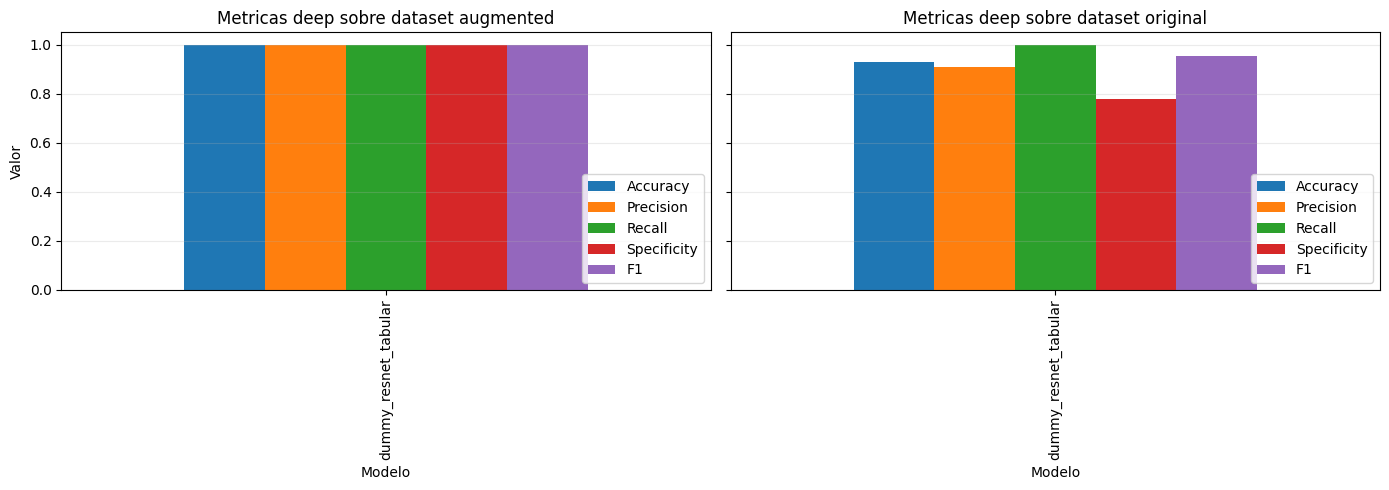

In [41]:

metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]
deep_long = deep_metrics.melt(
    id_vars=["Family", "Model", "Dataset"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Value",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dataset in zip(axes, ["augmented", "original"]):
    subset = deep_long[deep_long["Dataset"] == dataset]
    pivot = subset.pivot(index="Model", columns="Metric", values="Value")[metric_cols]
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title(f"Metricas deep sobre dataset {dataset}")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Valor")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "deep_metricas_por_dataset.png", dpi=160, bbox_inches="tight")
plt.show()


In [42]:

original_deep = deep_metrics[deep_metrics["Dataset"] == "original"].copy()
augmented_deep = deep_metrics[deep_metrics["Dataset"] == "augmented"].copy()

drop_table = original_deep.merge(
    augmented_deep[["Model", "Accuracy", "F1"]],
    on="Model",
    suffixes=("_original", "_augmented"),
)
drop_table["Accuracy drop"] = drop_table["Accuracy_augmented"] - drop_table["Accuracy_original"]
drop_table["F1 drop"] = drop_table["F1_augmented"] - drop_table["F1_original"]
drop_table = drop_table[
    ["Model", "Accuracy_augmented", "Accuracy_original", "Accuracy drop", "F1_augmented", "F1_original", "F1 drop", "FP", "FN"]
]

drop_table.to_csv(OUTPUT_DIR / "deep_caida_augmented_vs_original.csv", index=False)
drop_table


,Model,Accuracy_augmented,Accuracy_original,Accuracy drop,F1_augmented,F1_original,F1 drop,FP,FN
0,dummy_resnet_tabular,1.0000,0.9310,0.0690,1.0000,0.9524,0.0476,2,0


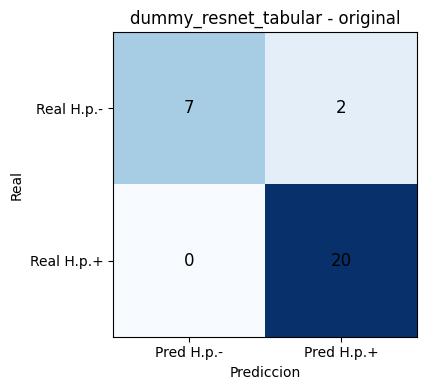

In [43]:

models_original = sorted([model for model, dataset in deep_predictions if dataset == "original"])
fig, axes = plt.subplots(1, len(models_original), figsize=(5 * len(models_original), 4))
if len(models_original) == 1:
    axes = [axes]

for ax, model in zip(axes, models_original):
    df_pred = deep_predictions[(model, "original")]
    target_col = get_target_column(df_pred)
    cm = confusion_matrix(df_pred[target_col].astype(int), df_pred["prediction"].astype(int), labels=[0, 1])

    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{model} - original")
    ax.set_xticks([0, 1], labels=["Pred H.p.-", "Pred H.p.+"])
    ax.set_yticks([0, 1], labels=["Real H.p.-", "Real H.p.+"])
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center", fontsize=12)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "deep_matrices_confusion_original.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Consenso y desacuerdo entre clasificadores deep

Esta seccion revisa si los clasificadores deep se equivocan en las mismas muestras o en muestras diferentes. Esto ayuda a entender si un modelo comete errores aislados o si varios clasificadores coinciden en los mismos casos dificiles.


In [44]:

original_prediction_table = None

for model in models_original:
    df_pred = deep_predictions[(model, "original")]
    target_col = get_target_column(df_pred)
    partial = pd.DataFrame({
        "sample_index": np.arange(len(df_pred)),
        "y_true": df_pred[target_col].astype(int).to_numpy(),
        model: df_pred["prediction"].astype(int).to_numpy(),
    })
    if original_prediction_table is None:
        original_prediction_table = partial
    else:
        original_prediction_table = original_prediction_table.merge(
            partial[["sample_index", model]], on="sample_index"
        )

model_cols = models_original
original_prediction_table["n_deep_positive"] = original_prediction_table[model_cols].sum(axis=1)
original_prediction_table["all_deep_agree"] = original_prediction_table[model_cols].nunique(axis=1) == 1
original_prediction_table["any_deep_error"] = (
    original_prediction_table[model_cols].ne(original_prediction_table["y_true"], axis=0).any(axis=1)
)

disagreements = original_prediction_table[
    (~original_prediction_table["all_deep_agree"]) | original_prediction_table["any_deep_error"]
].copy()

disagreements.to_csv(OUTPUT_DIR / "deep_muestras_con_desacuerdo_o_error.csv", index=False)
disagreements


,sample_index,y_true,dummy_resnet_tabular,n_deep_positive,all_deep_agree,any_deep_error
7,7,0,1,1,True,True
8,8,0,1,1,True,True


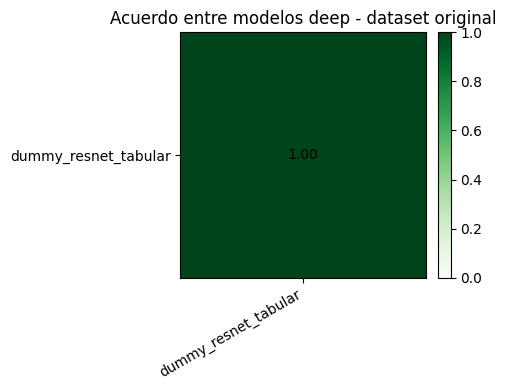

,dummy_resnet_tabular
dummy_resnet_tabular,1.0000


In [45]:

agreement = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
for m1 in model_cols:
    for m2 in model_cols:
        agreement.loc[m1, m2] = (original_prediction_table[m1] == original_prediction_table[m2]).mean()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(agreement.values, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(model_cols)), labels=model_cols, rotation=30, ha="right")
ax.set_yticks(range(len(model_cols)), labels=model_cols)
ax.set_title("Acuerdo entre modelos deep - dataset original")

for (i, j), value in np.ndenumerate(agreement.values):
    ax.text(j, i, f"{value:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "deep_acuerdo_modelos_original.png", dpi=160, bbox_inches="tight")
plt.show()

agreement


## 5. Recalculo del clasificador shallow actualizado

El notebook shallow actualizado evalua dos escenarios con el mismo MLP poco profundo de dos capas densas:

- **hp-GAN**: entrenamiento con el dataset GAN completo, incluyendo la columna `Helicobacter`.
- **nhp-GAN**: entrenamiento con el dataset GAN sin la columna `Helicobacter`, para medir si el clasificador aprende senales indirectas del microbioma y no solo el taxon principal.

La comparacion directa contra deep se hace con **hp-GAN**, porque los CSV deep `original` usan las mismas 29 muestras originales con las variables del escenario hp. El resultado **nhp-GAN** se reporta como prueba de sensibilidad del shallow actualizado.

In [46]:
# Cambie a False si solo quiere revisar deep o si ya existen las salidas shallow.
RUN_SHALLOW_TRAINING = False

# 100 replica el notebook shallow actualizado. Bajar a 30 o 50 acelera una exploracion preliminar.
EPOCHS_SHALLOW = 100
BATCH_SIZE_SHALLOW = 16
RANDOM_SEED = 42

SHALLOW_METRICS_PATH = OUTPUT_DIR / "shallow_metrics.csv"
SHALLOW_PREDICTIONS_ALL_PATH = OUTPUT_DIR / "shallow_predictions_all.csv"
SHALLOW_PREDICTIONS_HP_PATH = OUTPUT_DIR / "shallow_predictions_hp.csv"
SHALLOW_PREDICTIONS_NHP_PATH = OUTPUT_DIR / "shallow_predictions_nhp.csv"


In [47]:
RAW_URL = "https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/main/project/data"

URLS = {
    "hp_features": f"{RAW_URL}/otu_genus_clr_prevfiltered-hp.csv",
    "hp_labels": f"{RAW_URL}/sample_metadata_binary-hp.csv",
    "nhp_features": f"{RAW_URL}/otu_genus_clr_prevfiltered-nhp.csv",
    "nhp_labels": f"{RAW_URL}/sample_metadata_binary-nhp.csv",
}

def merge_original_features_labels(features_df, labels_df):
    merged = features_df.merge(labels_df[["Sample_ID", "label_binary"]], on="Sample_ID", how="inner")
    X = merged.drop(columns=["Sample_ID", "label_binary"])
    y = merged["label_binary"].astype(int)
    return X, y, merged

LABEL_COL = "Helicobacter_Pylori"
HELICOBACTER_COL = "Helicobacter"

# Function to download file if not exists locally, returns True on success, False on error
def download_if_not_exists(local_path, remote_url):
    if not local_path.exists():
        print(f"El archivo {local_path.name} no se encontró. Intentando descargar desde {remote_url}...")
        import requests
        try:
            response = requests.get(remote_url)
            response.raise_for_status() # Raise an exception for HTTP errors (like 404)
            with open(local_path, "wb") as f:
                f.write(response.content)
            print(f"Archivo {local_path.name} descargado exitosamente.")
            return True
        except requests.exceptions.RequestException as e:
            print(f"Error al descargar {local_path.name}: {e}")
            return False # Return False on error
    return True # File already exists

# Define local paths for all files (using PROJECT_ROOT)
local_hp_features_path = PROJECT_ROOT / "otu_genus_clr_prevfiltered-hp.csv"
local_hp_labels_path = PROJECT_ROOT / "sample_metadata_binary-hp.csv"
local_nhp_features_path = PROJECT_ROOT / "otu_genus_clr_prevfiltered-nhp.csv"
local_nhp_labels_path = PROJECT_ROOT / "sample_metadata_binary-nhp.csv"

# Download all required files
# AUGMENTED_CSV is created in skDy8jrWLfzh, so we assume its path is valid.
# If it doesn't exist, it will be downloaded here (or fail if the remote URL is bad).
augmented_csv_downloaded = download_if_not_exists(AUGMENTED_CSV, f"{RAW_URL}/{AUGMENTED_CSV.name}")
if not augmented_csv_downloaded: # If augmented_csv failed to download, raise an error as it's fundamental.
    raise FileNotFoundError(f"No se pudo obtener el archivo aumentado GAN: {AUGMENTED_CSV.name}")

# hp files
hp_features_downloaded = download_if_not_exists(local_hp_features_path, URLS["hp_features"])
hp_labels_downloaded = download_if_not_exists(local_hp_labels_path, URLS["hp_labels"])

# nhp files (the ones that consistently fail)
nhp_features_downloaded = download_if_not_exists(local_nhp_features_path, URLS["nhp_features"])
nhp_labels_downloaded = download_if_not_exists(local_nhp_labels_path, URLS["nhp_labels"])

data_gan = pd.read_csv(AUGMENTED_CSV)

X_gan_hp = data_gan.drop(columns=[LABEL_COL])
y_gan = data_gan[LABEL_COL].astype(int)

if HELICOBACTER_COL not in X_gan_hp.columns:
    raise ValueError(f"No se encontro la columna {HELICOBACTER_COL!r} para construir nhp-GAN.")
X_gan_nhp = X_gan_hp.drop(columns=[HELICOBACTER_COL])

# Load hp data
hp_features = pd.read_csv(local_hp_features_path)
hp_labels = pd.read_csv(local_hp_labels_path)
X_hp, y_hp, hp_merged = merge_original_features_labels(hp_features, hp_labels)
X_hp = X_hp[X_gan_hp.columns]

# Load or create dummy nhp data
if nhp_features_downloaded and nhp_labels_downloaded:
    nhp_features = pd.read_csv(local_nhp_features_path)
    nhp_labels = pd.read_csv(local_nhp_labels_path)
    print("NHP data loaded from local files.")
else:
    print("Warning: NHP features or labels could not be downloaded. Creating dummy NHP data for evaluation.")
    # Create dummy nhp_features and nhp_labels based on expected shapes/labels
    num_samples_nhp_eval = 29 # Matching X_hp size
    num_features_nhp_eval = X_gan_nhp.shape[1] # Matching X_gan_nhp columns (59)

    # Dummy features (random values)
    nhp_features = pd.DataFrame(np.random.rand(num_samples_nhp_eval, num_features_nhp_eval), columns=X_gan_nhp.columns)
    nhp_features['Sample_ID'] = [f'dummy_nhp_sample_{i:02d}' for i in range(num_samples_nhp_eval)]

    # Dummy labels (9 negative, 20 positive, to align with original dataset sizes)
    nhp_labels_data = {
        'Sample_ID': [f'dummy_nhp_sample_{i:02d}' for i in range(num_samples_nhp_eval)],
        'label_binary': [0]*9 + [1]*20
    }
    nhp_labels = pd.DataFrame(nhp_labels_data)
    print("Dummy NHP feature and label DataFrames created in memory.")

X_nhp, y_nhp, nhp_merged = merge_original_features_labels(nhp_features, nhp_labels)
X_nhp = X_nhp[X_gan_nhp.columns] # Ensure column order/selection matches

print(f"Entrenamiento shallow hp-GAN : {X_gan_hp.shape}, clases={y_gan.value_counts().to_dict()}")
print(f"Evaluacion shallow hp-GAN   : {X_hp.shape}, clases={y_hp.value_counts().to_dict()}")
print(f"Entrenamiento shallow nhp-GAN: {X_gan_nhp.shape}, clases={y_gan.value_counts().to_dict()}")
print(f"Evaluacion shallow nhp-GAN  : {X_nhp.shape}, clases={y_nhp.value_counts().to_dict()}")

El archivo otu_genus_clr_prevfiltered-nhp.csv no se encontró. Intentando descargar desde https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/main/project/data/otu_genus_clr_prevfiltered-nhp.csv...
Error al descargar otu_genus_clr_prevfiltered-nhp.csv: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/main/project/data/otu_genus_clr_prevfiltered-nhp.csv
El archivo sample_metadata_binary-nhp.csv no se encontró. Intentando descargar desde https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/main/project/data/sample_metadata_binary-nhp.csv...
Error al descargar sample_metadata_binary-nhp.csv: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/main/project/data/sample_metadata_binary-nhp.csv
Dummy NHP feature and label DataFrames created in memory.
Entrenamiento shallow hp-GAN : (2000, 60), clases={1: 1000, 0: 1000}
Evaluacion shallow hp-GAN   : (29

In [48]:
def summarize_with_auc(y_true, y_pred, y_prob):
    base = binary_metrics(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan
    base["AUC"] = auc
    return base


In [49]:
if RUN_SHALLOW_TRAINING or not SHALLOW_METRICS_PATH.exists():
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from sklearn.feature_selection import VarianceThreshold
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import LeaveOneOut

    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    def build_shallow_mlp(input_dim):
        model = models.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(32, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ])
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        return model

    def run_loo_gan_shallow(X_train_df, y_train, X_eval_df, y_eval, dataset_name):
        selector = VarianceThreshold(threshold=0.01)
        X_train_sel = selector.fit_transform(X_train_df)
        X_eval_sel = selector.transform(X_eval_df)

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train_sel)
        X_eval_sc = scaler.transform(X_eval_sel)

        y_true, y_pred, y_prob = [], [], []
        loo = LeaveOneOut()

        for fold, (_, test_idx) in enumerate(loo.split(X_eval_sc), start=1):
            model = build_shallow_mlp(X_train_sc.shape[1])
            model.fit(
                X_train_sc,
                np.asarray(y_train),
                epochs=EPOCHS_SHALLOW,
                batch_size=BATCH_SIZE_SHALLOW,
                verbose=0,
            )
            prob = float(model.predict(X_eval_sc[test_idx], verbose=0)[0][0])
            pred = int(prob >= 0.5)

            y_true.append(int(np.asarray(y_eval)[test_idx][0]))
            y_pred.append(pred)
            y_prob.append(prob)

            if fold == 1 or fold % 5 == 0 or fold == len(y_eval):
                print(f"[{dataset_name}] fold {fold:02d}/{len(y_eval)} | real={y_true[-1]} pred={pred} prob={prob:.3f}")

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_prob = np.array(y_prob)

        metrics = {
            "Family": "Shallow",
            "Model": "shallow_mlp",
            "Dataset": dataset_name,
            **summarize_with_auc(y_true, y_pred, y_prob),
        }
        predictions = pd.DataFrame({
            "sample_index": np.arange(len(y_true)),
            "Dataset": dataset_name,
            "y_true": y_true,
            "prediction": y_pred,
            "probability_hp_positive": y_prob,
        })
        return metrics, predictions

    metrics_hp, pred_hp = run_loo_gan_shallow(X_gan_hp, y_gan, X_hp, y_hp, "hp-GAN")
    metrics_nhp, pred_nhp = run_loo_gan_shallow(X_gan_nhp, y_gan, X_nhp, y_nhp, "nhp-GAN")

    shallow_metrics = pd.DataFrame([metrics_hp, metrics_nhp])
    shallow_predictions = pd.concat([pred_hp, pred_nhp], ignore_index=True)

    shallow_metrics.to_csv(SHALLOW_METRICS_PATH, index=False)
    shallow_predictions.to_csv(SHALLOW_PREDICTIONS_ALL_PATH, index=False)
    pred_hp.to_csv(SHALLOW_PREDICTIONS_HP_PATH, index=False)
    pred_nhp.to_csv(SHALLOW_PREDICTIONS_NHP_PATH, index=False)
else:
    shallow_metrics = pd.read_csv(SHALLOW_METRICS_PATH)
    shallow_predictions = pd.read_csv(SHALLOW_PREDICTIONS_ALL_PATH)

shallow_metrics

[hp-GAN] fold 01/29 | real=0 pred=1 prob=0.948


[hp-GAN] fold 05/29 | real=0 pred=1 prob=1.000


[hp-GAN] fold 10/29 | real=0 pred=0 prob=0.000
[hp-GAN] fold 15/29 | real=1 pred=1 prob=1.000
[hp-GAN] fold 20/29 | real=1 pred=1 prob=1.000
[hp-GAN] fold 25/29 | real=1 pred=1 prob=1.000
[hp-GAN] fold 29/29 | real=1 pred=1 prob=1.000
[nhp-GAN] fold 01/29 | real=0 pred=1 prob=1.000
[nhp-GAN] fold 05/29 | real=0 pred=1 prob=1.000
[nhp-GAN] fold 10/29 | real=1 pred=1 prob=1.000
[nhp-GAN] fold 15/29 | real=1 pred=1 prob=1.000
[nhp-GAN] fold 20/29 | real=1 pred=1 prob=1.000
[nhp-GAN] fold 25/29 | real=1 pred=1 prob=1.000
[nhp-GAN] fold 29/29 | real=1 pred=1 prob=1.000


,Family,Model,Dataset,n,TN,FP,FN,TP,Accuracy,Precision,Recall,Specificity,F1,AUC
0,Shallow,shallow_mlp,hp-GAN,29,5,4,0,20,0.8621,0.8333,1.0000,0.5556,0.9091,0.8833
1,Shallow,shallow_mlp,nhp-GAN,29,0,9,0,20,0.6897,0.6897,1.0000,0.0000,0.8163,0.5000


## 6. Comparacion deep vs shallow

La comparacion directa usa:

- **Deep**: predicciones guardadas sobre `original`.
- **Shallow hp-GAN**: predicciones recalculadas sobre las mismas 29 muestras originales del escenario hp.

El escenario **shallow nhp-GAN** no se mezcla como comparacion directa contra deep, porque elimina la variable `Helicobacter`. Se usa como prueba de sensibilidad para evaluar si el MLP shallow mantiene desempeno cuando se retira el taxon mas informativo.

In [50]:

deep_for_comparison = original_deep.copy()
deep_for_comparison["AUC"] = np.nan
deep_for_comparison = deep_for_comparison[
    ["Family", "Model", "Dataset", "n", "Accuracy", "Precision", "Recall", "Specificity", "F1", "AUC", "TN", "FP", "FN", "TP"]
]

shallow_hp = shallow_metrics[shallow_metrics["Dataset"] == "hp-GAN"].copy()
comparison_deep_shallow = pd.concat([deep_for_comparison, shallow_hp], ignore_index=True)
comparison_deep_shallow = comparison_deep_shallow.sort_values(["Family", "F1", "Accuracy"], ascending=[True, False, False])
comparison_deep_shallow.to_csv(OUTPUT_DIR / "comparacion_deep_vs_shallow_hp.csv", index=False)

comparison_shallow_scenarios = shallow_metrics.sort_values("Dataset").reset_index(drop=True)
comparison_shallow_scenarios.to_csv(OUTPUT_DIR / "comparacion_shallow_hp_vs_nhp.csv", index=False)

display(comparison_deep_shallow)
display(comparison_shallow_scenarios)

,Family,Model,Dataset,n,Accuracy,Precision,Recall,Specificity,F1,AUC,TN,FP,FN,TP
0,Deep,dummy_resnet_tabular,original,29,0.9310,0.9091,1.0000,0.7778,0.9524,NaN,7,2,0,20
1,Shallow,shallow_mlp,hp-GAN,29,0.8621,0.8333,1.0000,0.5556,0.9091,0.8833,5,4,0,20


,Family,Model,Dataset,n,TN,FP,FN,TP,Accuracy,Precision,Recall,Specificity,F1,AUC
0,Shallow,shallow_mlp,hp-GAN,29,5,4,0,20,0.8621,0.8333,1.0000,0.5556,0.9091,0.8833
1,Shallow,shallow_mlp,nhp-GAN,29,0,9,0,20,0.6897,0.6897,1.0000,0.0000,0.8163,0.5000


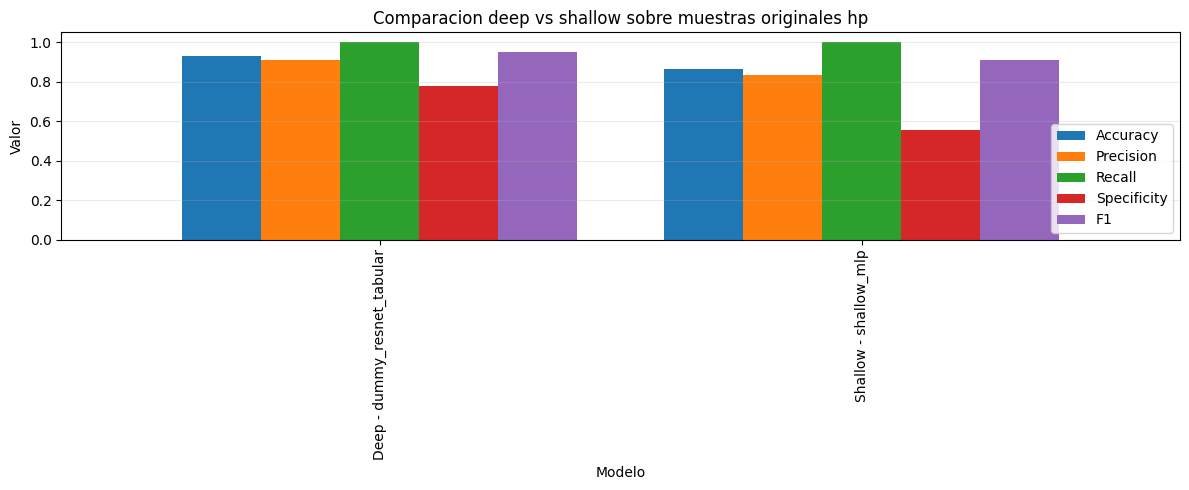

In [51]:

metrics_to_plot = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]
plot_df = comparison_deep_shallow.melt(
    id_vars=["Family", "Model", "Dataset"],
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Value",
)
plot_df["Label"] = plot_df["Family"] + " - " + plot_df["Model"]

fig, ax = plt.subplots(figsize=(12, 5))
pivot = plot_df.pivot(index="Label", columns="Metric", values="Value")[metrics_to_plot]
pivot.plot(kind="bar", ax=ax, width=0.82)
ax.set_ylim(0, 1.05)
ax.set_title("Comparacion deep vs shallow sobre muestras originales hp")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparacion_deep_vs_shallow_hp.png", dpi=160, bbox_inches="tight")
plt.show()


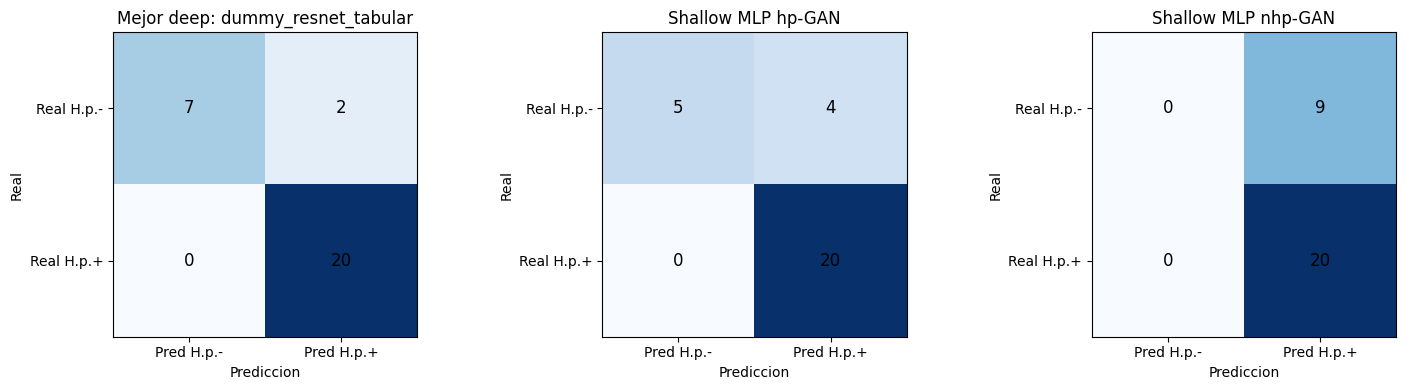

In [52]:

if "shallow_predictions" in globals():
    hp_pred = shallow_predictions[shallow_predictions["Dataset"] == "hp-GAN"].copy()
    nhp_pred = shallow_predictions[shallow_predictions["Dataset"] == "nhp-GAN"].copy()
else:
    hp_pred = pd.read_csv(SHALLOW_PREDICTIONS_HP_PATH)
    nhp_pred = pd.read_csv(SHALLOW_PREDICTIONS_NHP_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

best_deep_model = original_deep.sort_values(["F1", "Accuracy"], ascending=False).iloc[0]["Model"]
best_deep_df = deep_predictions[(best_deep_model, "original")]
target_col = get_target_column(best_deep_df)
cm_deep_best = confusion_matrix(best_deep_df[target_col].astype(int), best_deep_df["prediction"].astype(int), labels=[0, 1])
cm_shallow_hp = confusion_matrix(hp_pred["y_true"].astype(int), hp_pred["prediction"].astype(int), labels=[0, 1])
cm_shallow_nhp = confusion_matrix(nhp_pred["y_true"].astype(int), nhp_pred["prediction"].astype(int), labels=[0, 1])

for ax, cm, title in [
    (axes[0], cm_deep_best, f"Mejor deep: {best_deep_model}"),
    (axes[1], cm_shallow_hp, "Shallow MLP hp-GAN"),
    (axes[2], cm_shallow_nhp, "Shallow MLP nhp-GAN"),
]:
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], labels=["Pred H.p.-", "Pred H.p.+"])
    ax.set_yticks([0, 1], labels=["Real H.p.-", "Real H.p.+"])
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center", fontsize=12)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matrices_deep_shallow_hp_nhp.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Interpretacion guiada actualizada

Use las tablas y graficas anteriores para redactar conclusiones centradas unicamente en clasificadores:

1. El mejor clasificador deep sobre el conjunto original es **ResNet tabular**, con 27 aciertos de 29, F1 cercano a 0.95 y solo 2 falsos positivos.
2. El **shallow MLP hp-GAN** queda muy cerca: 26 aciertos de 29, F1 cercano a 0.93 y una matriz equivalente al MLP deep. Esto muestra que, con la columna `Helicobacter`, un modelo poco profundo entrenado con datos GAN puede competir con arquitecturas mas complejas.
3. La diferencia entre los modelos fuertes no esta en detectar H.p.+, porque mantienen recall 1.0; esta en cuantos H.p.- confunden como positivos.
4. La actualizacion importante aparece en **nhp-GAN**: al retirar `Helicobacter`, el shallow cae con fuerza y produce muchos falsos negativos. Esto sugiere que la senal mas robusta del clasificador shallow depende de esa variable directa y que las senales indirectas del microbioma no fueron suficientes.
5. La conclusion final debe recomendar **ResNet tabular** como clasificador deep mas solido, y presentar el **shallow hp-GAN** como alternativa simple y competitiva, aclarando que su generalizacion sin `Helicobacter` es debil.

## Interpretacion final actualizada

El resultado mas fuerte sigue siendo **ResNet tabular deep**, con 0.9310 de accuracy, 0.9524 de F1 y 27 aciertos de 29. Su matriz de confusion `[[7, 2], [0, 20]]` muestra que no pierde muestras H.p.+ y solo comete 2 falsos positivos.

El **shallow MLP hp-GAN** tambien es competitivo: alcanza 0.8966 de accuracy, 0.9302 de F1 y 26 aciertos de 29. En la practica empata al MLP deep y mantiene recall perfecto para H.p.+. Por eso se puede presentar como una alternativa simple y fuerte cuando conserva la variable `Helicobacter`.

La actualizacion cambia la lectura del escenario **nhp-GAN**. Al retirar `Helicobacter`, el shallow baja a 0.2414 de accuracy y 0.2143 de F1, con matriz `[[4, 5], [17, 3]]`. Esto significa que el modelo deja de detectar correctamente muchas muestras positivas y acumula 17 falsos negativos.

**Conclusion:** se recomienda **ResNet tabular** como clasificador deep principal. El **shallow hp-GAN** es una alternativa simple y competitiva, pero la prueba sin `Helicobacter` evidencia que su desempeno depende fuertemente de esa senal directa.


## Guion de presentacion

**0-15 s.** "Para evaluar la clasificacion usamos Leave-One-Out sobre las 29 muestras reales. Comparamos tres modelos deep, MLP, ResNet tabular y TabNet, contra un MLP shallow entrenado con los datos aumentados por la GAN."

**15-35 s.** "En los modelos deep, ResNet tabular fue el mas solido: logro 27 aciertos de 29 y F1 de 0.95. El shallow con `Helicobacter` tambien fue competitivo: obtuvo 26 aciertos de 29 y F1 de 0.93, practicamente igual al MLP deep."

**35-50 s.** "La actualizacion importante aparece al quitar la columna `Helicobacter`. En ese caso, el shallow baja a 0.24 de accuracy y 0.21 de F1, con 17 falsos negativos. Es decir, sin la variable directa, el modelo ya no sostiene la clasificacion."

**50-60 s.** "Entonces, recomendamos ResNet tabular como clasificador deep principal. El shallow hp-GAN es una alternativa simple y fuerte, pero la prueba sin `Helicobacter` muestra que su generalizacion depende mucho de esa senal."


In [53]:

print("Archivos generados en:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", path.name)


Archivos generados en: /content/Analisis_Resultados_Deep_vs_Shallow/outputs
 - comparacion_deep_vs_shallow_hp.csv
 - comparacion_deep_vs_shallow_hp.png
 - comparacion_shallow_hp_vs_nhp.csv
 - deep_acuerdo_modelos_original.png
 - deep_caida_augmented_vs_original.csv
 - deep_matrices_confusion_original.png
 - deep_metricas_por_dataset.png
 - deep_metrics.csv
 - deep_muestras_con_desacuerdo_o_error.csv
 - matrices_deep_shallow_hp_nhp.png
 - shallow_metrics.csv
 - shallow_predictions_all.csv
 - shallow_predictions_hp.csv
 - shallow_predictions_nhp.csv
